# Librerías y carga de datos

In [58]:
import river
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from scipy import stats as spstats
# import labelencoder
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
# PCA
from sklearn.decomposition import PCA
import plotly.express as px
# math y river
import math
from river import stats
from river import cluster
from river import preprocessing as river_prep
from river import anomaly

In [43]:

# Carga de datos
df = pd.read_csv('sensor.csv')

# Limpieza inicial
df = df.drop(columns=['Unnamed: 0'], errors='ignore') # Eliminar columna de índice si existe
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Mapear el estado real de la máquina para evaluación futura
# Asumimos que "NORMAL" y "RECOVERING" es 0 (no anomalía) y "BROKEN" es 1 (anomalía)
if 'machine_status' in df.columns:
    df['is_anomaly_real'] = df['machine_status'].apply(lambda x: 1 if x == 'BROKEN' else 0)

df.isna().sum()


sensor_00           10208
sensor_01             369
sensor_02              19
sensor_03              19
sensor_04              19
sensor_05              19
sensor_06            4798
sensor_07            5451
sensor_08            5107
sensor_09            4595
sensor_10              19
sensor_11              19
sensor_12              19
sensor_13              19
sensor_14              21
sensor_15          220320
sensor_16              31
sensor_17              46
sensor_18              46
sensor_19              16
sensor_20              16
sensor_21              16
sensor_22              41
sensor_23              16
sensor_24              16
sensor_25              36
sensor_26              20
sensor_27              16
sensor_28              16
sensor_29              72
sensor_30             261
sensor_31              16
sensor_32              68
sensor_33              16
sensor_34              16
sensor_35              16
sensor_36              16
sensor_37              16
sensor_38   

In [44]:
df = df.drop_duplicates()
df.drop(columns=['sensor_15'], inplace=True, errors='ignore')
df.shape

(217444, 53)

In [45]:
numeric_columns = df.filter(regex='sensor').columns
df[numeric_columns] = df[numeric_columns].fillna(method='ffill').fillna(0)

df.isna().sum()


C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\210784236.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_columns] = df[numeric_columns].fillna(method='ffill').fillna(0)


sensor_00          0
sensor_01          0
sensor_02          0
sensor_03          0
sensor_04          0
sensor_05          0
sensor_06          0
sensor_07          0
sensor_08          0
sensor_09          0
sensor_10          0
sensor_11          0
sensor_12          0
sensor_13          0
sensor_14          0
sensor_16          0
sensor_17          0
sensor_18          0
sensor_19          0
sensor_20          0
sensor_21          0
sensor_22          0
sensor_23          0
sensor_24          0
sensor_25          0
sensor_26          0
sensor_27          0
sensor_28          0
sensor_29          0
sensor_30          0
sensor_31          0
sensor_32          0
sensor_33          0
sensor_34          0
sensor_35          0
sensor_36          0
sensor_37          0
sensor_38          0
sensor_39          0
sensor_40          0
sensor_41          0
sensor_42          0
sensor_43          0
sensor_44          0
sensor_45          0
sensor_46          0
sensor_47          0
sensor_48    

In [46]:
labels = df['is_anomaly_real'].values

In [47]:
df_offline = df[numeric_columns].copy()

(217444, 2)
          PC1         PC2  is_anomaly_real
0 -102.948381 -285.996713                0
1  -61.984623 -295.823524                0
2  -58.856349 -298.686546                0
3  -63.978455 -304.597389                0
4  -78.980365 -295.745253                0


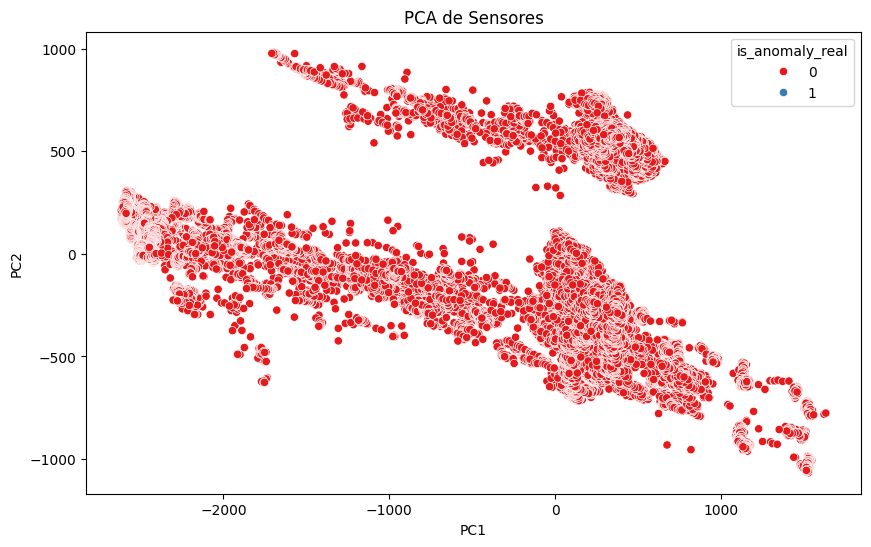

In [48]:
# PCA 2 componentes para visualización
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_offline.values)
print(df_pca.shape)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['is_anomaly_real'] = labels 
print(df_pca.head()) 
# Visualización PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='is_anomaly_real', palette='Set1')
plt.title('PCA de Sensores')
plt.show()


Para este estudio, vamos a utilizar únicamnete los datos de un solo sensor y para obtener resulados razonables, cogemos el sensor con mayor correlación con el resto de sentores puesto que las lables en esta práctica son orientativas. Para esto, se ha realizado un estudio de correlación entre los sensores y se ha seleccionado el sensor que presenta la mayor correlación.


In [49]:
# Calular la matriz de correlación de un sensor con el resto de sensores y la variable objetivo
corr_sensores = df_offline.corr()

# Quitamos la autocorrelación (diagonal = 1)
np.fill_diagonal(corr_sensores.values, np.nan)

# Calculamos la correlación media absoluta con los demás sensores
mean_corr = corr_sensores.abs().mean().sort_values(ascending=False)

top5_media = mean_corr.head(5)

top5_media


sensor_23    0.410419
sensor_22    0.403666
sensor_19    0.400407
sensor_21    0.400168
sensor_20    0.399657
dtype: float64

Por tanto en sensor seleccionado es el sensor 23, que presenta una correlación de 0.41 con el resto de sensores.

In [50]:
df_offline = df_offline[df.columns[:-2]].copy()

In [51]:
df_offline.head()

,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,...,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889
2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,...,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037
2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,15.08247,...,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250
2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,15.08247,...,31.510420,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889
2018-04-01 00:05:00,2.453588,47.09201,53.1684,46.397568,637.6157,78.18568,13.41146,16.16753,15.89265,15.16204,...,31.250000,42.70833,38.773150,63.65741,51.79398,38.773150,164.6412,66.55093,241.6088,201.6782


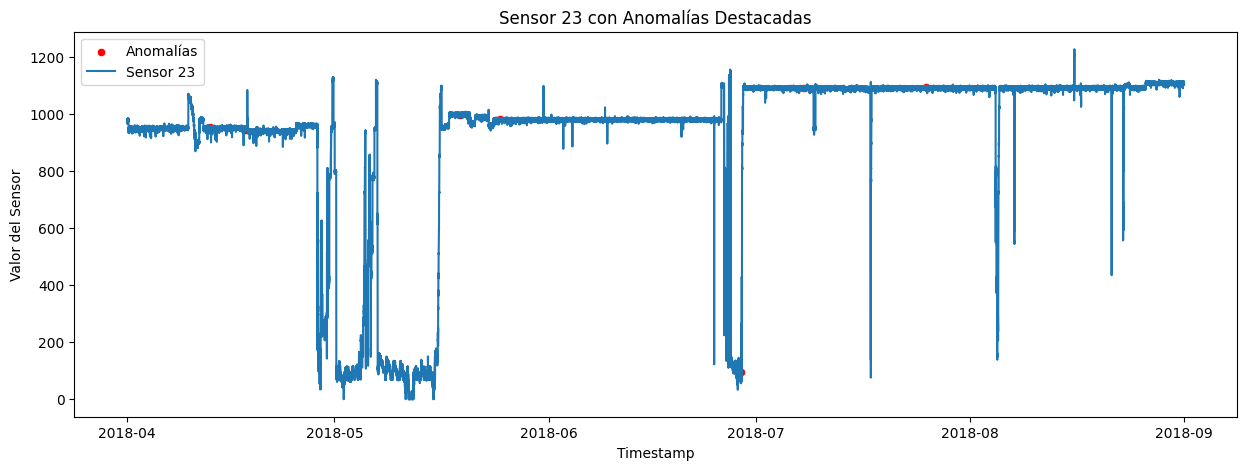

In [52]:
# plot sensor 23 con azul si es normal y rojo si es anómalo, es una serie temporal, por lo que el eje x es el índice del dataframe, plotea anomalias como plot scatter y el resto como lineplot
plt.figure(figsize=(15, 5))
sns.scatterplot(data=df_offline[df['is_anomaly_real'] == 1], x=df_offline[df['is_anomaly_real'] == 1].index, y='sensor_23', color='red', label='Anomalías')
sns.lineplot(data=df_offline, x=df_offline.index, y='sensor_23', label='Sensor 23')
plt.title('Sensor 23 con Anomalías Destacadas')
plt.xlabel('Timestamp')
plt.ylabel('Valor del Sensor')
plt.legend()
plt.show()

# Detección de anomalías con full dataset (offline)

En el análisis offline procesamos todo el conjunto de datos a la vez. Es computacionalmente rápido cuando los datos caben en memoria, pero no es capaz de adaptarse de forma nativa a cambios de concepto (Concept Drift), como fluctuaciones estacionales en la temperatura de la bomba.

### Rango Intercuartil (IQR)

El IQR es un método estadístico no paramétrico. Calcula la dispersión central de los datos ($IQR = Q3 - Q1$) y marca como anomalía cualquier punto que se aleje en un factor (usualmente 1.5) de los cuartiles. Limitación: Evalúa cada sensor de manera independiente (univariante) y no detecta relaciones complejas.

In [53]:
def iqr_offline(df_data, factor=1.5):
    anomalies = pd.DataFrame(index=df_data.index)
    for col in df_data.columns:
        Q1 = df_data[col].quantile(0.25)
        Q3 = df_data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - (factor * IQR)
        upper_bound = Q3 + (factor * IQR)
        
        # Guardar True donde hay anomalía
        anomalies[col] = (df_data[col] < lower_bound) | (df_data[col] > upper_bound)
    
    # Si cualquier sensor da anomalía, marcamos la fila como anomalía global
    return anomalies.any(axis=1).astype(int)

df['anomaly_iqr_batch'] = iqr_offline(df_offline, factor=1.5)
print(f"Anomalías detectadas por IQR (Offline): {df['anomaly_iqr_batch'].sum()}")

Anomalías detectadas por IQR (Offline): 160140


### Z-Score (Media y Desviación Estándar)

El método Z-Score asume que los datos se distribuyen de forma normal (Gaussiana). Calcula a cuántas desviaciones estándar ($\sigma$) se encuentra un valor respecto a la media ($\mu$). Valores más allá de un umbral k (por ejemplo, 3 desviaciones) se consideran anómalos.

In [54]:
def zscore_offline(df_data, k=3):
    anomalies = pd.DataFrame(index=df_data.index)
    for col in df_data.columns:
        mean = df_data[col].mean()
        std = df_data[col].std()
        
        if std == 0: # Evitar divisiones por cero
            anomalies[col] = False
            continue
            
        z_scores = np.abs((df_data[col] - mean) / std)
        anomalies[col] = z_scores > k
        
    return anomalies.any(axis=1).astype(int)

df['anomaly_zscore_batch'] = zscore_offline(df_offline, k=3)
print(f"Anomalías detectadas por Z-Score (Offline): {df['anomaly_zscore_batch'].sum()}")

Anomalías detectadas por Z-Score (Offline): 63847


### K-Means Clustering (Experimentos con n_clusters)

K-Means agrupa los datos en $K$ clústeres. La premisa para la detección de anomalías es que las observaciones normales estarán muy cerca de los centroides de su clúster, mientras que las anomalías estarán lejos.
Realizaremos experimentos con diferentes números de clústeres para ver cómo afecta a las detecciones. Usaremos el percentil 99 de las distancias como umbral para marcar el 1% de datos más extremos como anomalías.

In [55]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Escalar los datos offline
scaler_offline = StandardScaler()
data_scaled = scaler_offline.fit_transform(df_offline)

# Experimentos con distintos K
experimentos_k = [1, 2, 3, 4, 5]

for k in experimentos_k:
    print(f"\n--- Entrenando K-Means con {k} clusters ---")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(data_scaled)
    
    # Calcular distancias al centroide
    distances = []
    for i, point in enumerate(data_scaled):
        centroid = kmeans.cluster_centers_[clusters[i]]
        dist = np.linalg.norm(point - centroid)
        distances.append(dist)
        
    # Definir umbral como el percentil 95 (el 5% más lejano)
    threshold = np.percentile(distances, 95)
    anomalias = (np.array(distances) > threshold).astype(int)
    
    df[f'anomaly_kmeans_batch_{k}'] = anomalias
    print(f"Umbral de distancia: {threshold:.2f}")
    print(f"Anomalías detectadas: {sum(anomalias)}")


--- Entrenando K-Means con 1 clusters ---
Umbral de distancia: 13.34
Anomalías detectadas: 10873

--- Entrenando K-Means con 2 clusters ---
Umbral de distancia: 12.32
Anomalías detectadas: 10873

--- Entrenando K-Means con 3 clusters ---
Umbral de distancia: 7.72
Anomalías detectadas: 10873

--- Entrenando K-Means con 4 clusters ---
Umbral de distancia: 7.54
Anomalías detectadas: 10873

--- Entrenando K-Means con 5 clusters ---
Umbral de distancia: 7.54
Anomalías detectadas: 10873


### Isolation Forest (Experimentos con contamination)

A diferencia de aislar lo "normal", Isolation Forest se centra explícitamente en aislar las anomalías. Crea árboles aleatorios; las anomalías, al ser diferentes y escasas, requieren menos cortes (profundidad del árbol) para ser aisladas. Experimentaremos con la tasa esperada de ruido (contamination).

In [56]:
from sklearn.ensemble import IsolationForest

# Experimentos con distinta contaminación
tasas_ruido = [0.01, 0.05, 0.10, 0.15] # Esperamos un 1%, 5%, 10% y 15% de anomalías

for contaminacion in tasas_ruido:
    print(f"\n--- Entrenando Isolation Forest con contamination={contaminacion} ---")
    iso_forest = IsolationForest(contamination=contaminacion, random_state=42, n_jobs=-1)
    
    # predict() devuelve 1 para normal y -1 para anomalía. Lo convertimos a 0 y 1.
    predicciones = iso_forest.fit_predict(data_scaled)
    anomalias = np.where(predicciones == -1, 1, 0)
    
    df[f'anomaly_iforest_batch_{contaminacion}'] = anomalias
    print(f"Anomalías detectadas: {sum(anomalias)}")


--- Entrenando Isolation Forest con contamination=0.01 ---
Anomalías detectadas: 2175

--- Entrenando Isolation Forest con contamination=0.05 ---
Anomalías detectadas: 10873

--- Entrenando Isolation Forest con contamination=0.1 ---
Anomalías detectadas: 21745

--- Entrenando Isolation Forest con contamination=0.15 ---
Anomalías detectadas: 32617


# Análisis Incremental (Streaming) con river

En la realidad industrial, los datos llegan uno a uno. Los métodos online se adaptan iterativamente, ajustando sus métricas internas y olvidando patrones obsoletos (Concept Drift). Esto permite que el umbral de lo que es "anómalo" varíe dinámicamente según el contexto.

In [57]:
from river import cluster
from river import preprocessing as river_prep
n_clusters = [1, 2, 3, 4, 5]
halflife = [0.1, 0.5, 0.9]

for k in n_clusters:
    for hl in halflife:
        print(f"\n--- Entrenando K-Means Incremental con {k} clusters y halflife={hl} ---")
        # Escalador incremental
        scaler_river = river_prep.StandardScaler()
        # Modelo incremental
        kmeans_online = cluster.KMeans(n_clusters=k, halflife=hl, seed=42)

        threshold_online = 2.5
        anomalies_kmeans_online = []
        dists = []
        for i, row in df_offline.iterrows():
            # Convertir fila a diccionario para River
            x = row.to_dict()
            
            # Estandarizar
            scaler_river.learn_one(x)
            x_scaled = scaler_river.transform_one(x)
            
            # Predecir
            cluster_id = kmeans_online.predict_one(x_scaled)
            centroids = kmeans_online.centers
            
            is_anom = 0
            if centroids:
                centroid = centroids[cluster_id]
                # Calcular distancia euclídea manual
                dist = math.sqrt(sum((x_scaled[f] - centroid[f])**2 for f in x_scaled))
                if dist > threshold_online:
                    is_anom = 1
                    
            anomalies_kmeans_online.append(is_anom)
            dists.append(dist)
            # Aprender
            kmeans_online.learn_one(x_scaled)

        df[f'anomaly_kmeans_online_{k}_{hl}'] = anomalies_kmeans_online
        print(f"Anomalías detectadas por K-Means Incremental con {k} clusters y halflife={hl}: {sum(anomalies_kmeans_online)}")


--- Entrenando K-Means Incremental con 1 clusters y halflife=0.1 ---
Anomalías detectadas por K-Means Incremental con 1 clusters y halflife=0.1: 28446

--- Entrenando K-Means Incremental con 1 clusters y halflife=0.5 ---
Anomalías detectadas por K-Means Incremental con 1 clusters y halflife=0.5: 13952

--- Entrenando K-Means Incremental con 1 clusters y halflife=0.9 ---
Anomalías detectadas por K-Means Incremental con 1 clusters y halflife=0.9: 14906

--- Entrenando K-Means Incremental con 2 clusters y halflife=0.1 ---
Anomalías detectadas por K-Means Incremental con 2 clusters y halflife=0.1: 28426

--- Entrenando K-Means Incremental con 2 clusters y halflife=0.5 ---
Anomalías detectadas por K-Means Incremental con 2 clusters y halflife=0.5: 13946

--- Entrenando K-Means Incremental con 2 clusters y halflife=0.9 ---
Anomalías detectadas por K-Means Incremental con 2 clusters y halflife=0.9: 14904

--- Entrenando K-Means Incremental con 3 clusters y halflife=0.1 ---
Anomalías detectad

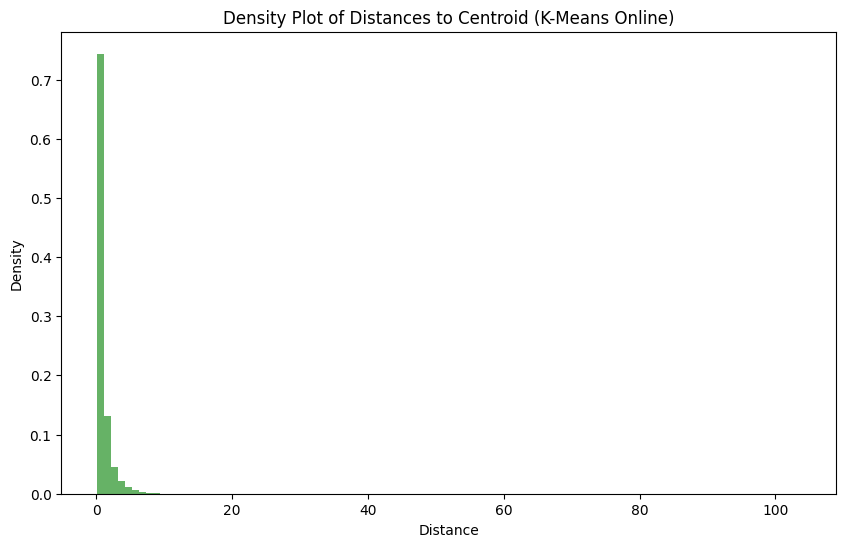

Distancia media al centroide: 0.95
Distancia máxima al centroide: 103.78
Distancia al centroide en el percentil 95: 2.97


In [59]:
# density plot of distnaces
plt.figure(figsize=(10, 6))
plt.hist(dists, bins=100, density=True, alpha=0.6, color='g')
plt.title('Density Plot of Distances to Centroid (K-Means Online)')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.show()
print(f"Distancia media al centroide: {np.mean(dists):.2f}")
print(f"Distancia máxima al centroide: {np.max(dists):.2f}")
# 90 percentil
print(f"Distancia al centroide en el percentil 95: {np.percentile(dists, 95):.2f}")

In [60]:
import itertools
import time
from river import preprocessing as river_prep
from river import anomaly
import pandas as pd

# Definición de todos los hiperparámetros a explorar
experimentos_trees = [5, 10, 30, 50]
window_sizes = [250, 1000, 5000]
alturas = [8, 12, 15]
umbrales_hst = [0.8, 0.9, 0.95, 0.99]

# Lista para guardar un registro de todos los experimentos (útil para conclusiones)
registro_experimentos = []

# Iteramos sobre la "arquitectura" del modelo (árboles, ventana, altura)
# itertools.product genera todas las combinaciones posibles de estas 3 listas
for n_trees, w_size, height in itertools.product(experimentos_trees, window_sizes, alturas):
    print(f"\n--- Entrenando HST: n_trees={n_trees}, window={w_size}, height={height} ---")
    
    start_time = time.time() # Iniciar cronómetro
    
    # Inicializar escalador y modelo
    scaler_hst = river_prep.StandardScaler()
    hst = anomaly.HalfSpaceTrees(n_trees=n_trees, height=height, window_size=w_size, seed=42)
    
    # Aquí guardaremos el score decimal puro de River, NO el 0 o 1
    raw_scores = []
    
    # Bucle principal de streaming
    for i, row in df_offline.iterrows(): # Asegúrate de que df_offline solo tiene los sensores
        x = row.to_dict()
        
        # 1. Escalar (online)
        scaler_hst.learn_one(x)
        x_scaled = scaler_hst.transform_one(x)
        
        # 2. Puntuar
        if hst.n_trees > 0:
            score = hst.score_one(x_scaled)
        else:
            score = 0
            
        raw_scores.append(score)
        
        # 3. Entrenar el modelo con la nueva observación
        hst.learn_one(x_scaled)
        
    elapsed_time = time.time() - start_time
    print(f"Entrenamiento completado en {elapsed_time:.2f} segundos.")
    
    # 4. AHORA aplicamos todos los umbrales al resultado de este entrenamiento
    for umbral in umbrales_hst:
        # Convertir scores brutos a 0 (Normal) o 1 (Anomalía)
        anomalies_hst = [1 if s > umbral else 0 for s in raw_scores]
        
        # Guardar en el DataFrame con un nombre de columna único
        col_name = f'anomaly_hst_t{n_trees}_w{w_size}_h{height}_u{umbral}'
        df[col_name] = anomalies_hst
        
        num_anomalias = sum(anomalies_hst)
        print(f"  -> Con umbral {umbral}: {num_anomalias} anomalías detectadas.")
        
        # Guardar metadatos para futura tabla comparativa
        registro_experimentos.append({
            'Modelo': 'HST (River)',
            'n_trees': n_trees,
            'window_size': w_size,
            'height': height,
            'threshold': umbral,
            'Anomalias_Detectadas': num_anomalias,
            'Tiempo_Entrenamiento_s': round(elapsed_time, 2),
            'Columna_DF': col_name
        })

# Al final, puedes convertir el registro en un DataFrame para visualizar un resumen
df_resumen_hst = pd.DataFrame(registro_experimentos)
print("\n--- Resumen de Experimentos HST Generado ---")
display(df_resumen_hst.head()) # Muestra las primeras combinaciones


--- Entrenando HST: n_trees=5, window=250, height=8 ---
Entrenamiento completado en 19.37 segundos.
  -> Con umbral 0.8: 33398 anomalías detectadas.
  -> Con umbral 0.9: 12083 anomalías detectadas.
  -> Con umbral 0.95: 5745 anomalías detectadas.
  -> Con umbral 0.99: 614 anomalías detectadas.

--- Entrenando HST: n_trees=5, window=250, height=12 ---
Entrenamiento completado en 31.10 segundos.
  -> Con umbral 0.8: 93395 anomalías detectadas.
  -> Con umbral 0.9: 45115 anomalías detectadas.
  -> Con umbral 0.95: 26356 anomalías detectadas.
  -> Con umbral 0.99: 11335 anomalías detectadas.

--- Entrenando HST: n_trees=5, window=250, height=15 ---
Entrenamiento completado en 119.49 segundos.
  -> Con umbral 0.8: 137973 anomalías detectadas.
  -> Con umbral 0.9: 83477 anomalías detectadas.
  -> Con umbral 0.95: 51510 anomalías detectadas.
  -> Con umbral 0.99: 24891 anomalías detectadas.

--- Entrenando HST: n_trees=5, window=1000, height=8 ---
Entrenamiento completado en 19.14 segundos.


C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = anomalies_hst
C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = anomalies_hst
C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

Entrenamiento completado en 19.12 segundos.
  -> Con umbral 0.8: 84330 anomalías detectadas.
  -> Con umbral 0.9: 38092 anomalías detectadas.
  -> Con umbral 0.95: 19154 anomalías detectadas.
  -> Con umbral 0.99: 2818 anomalías detectadas.

--- Entrenando HST: n_trees=5, window=5000, height=12 ---


C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = anomalies_hst
C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = anomalies_hst
C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

Entrenamiento completado en 22.49 segundos.
  -> Con umbral 0.8: 173316 anomalías detectadas.
  -> Con umbral 0.9: 117773 anomalías detectadas.
  -> Con umbral 0.95: 79358 anomalías detectadas.
  -> Con umbral 0.99: 44978 anomalías detectadas.

--- Entrenando HST: n_trees=5, window=5000, height=15 ---


...

Entrenamiento completado en 51.51 segundos.
  -> Con umbral 0.8: 21992 anomalías detectadas.
  -> Con umbral 0.9: 7546 anomalías detectadas.
  -> Con umbral 0.95: 2450 anomalías detectadas.
  -> Con umbral 0.99: 1 anomalías detectadas.

--- Entrenando HST: n_trees=30, window=250, height=12 ---


C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = anomalies_hst
C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = anomalies_hst
C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

Entrenamiento completado en 119.04 segundos.
  -> Con umbral 0.8: 85500 anomalías detectadas.
  -> Con umbral 0.9: 30603 anomalías detectadas.
  -> Con umbral 0.95: 14559 anomalías detectadas.
  -> Con umbral 0.99: 3772 anomalías detectadas.

--- Entrenando HST: n_trees=30, window=250, height=15 ---


C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = anomalies_hst
C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = anomalies_hst
C:\Users\vramo\AppData\Local\Temp\ipykernel_23052\3035996376.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

KeyboardInterrupt: 

# Evaluación de Modelos (Métricas F1, Precision, Recall)

Finalmente, cruzaremos las anomalías detectadas por todos los modelos contra la variable real de estado de la máquina is_anomaly_real. Dado que los fallos son eventos críticos y poco frecuentes, el F1-Score y el Recall (poder detectar todos los fallos para evitar desastres en la bomba) son nuestras métricas principales.

In [61]:
# Mostrar tabla resumen de métricas
resultados = []

columnas_modelos = [col for col in df.columns if 'anomaly_' in col and col != 'is_anomaly_real']

for col in columnas_modelos:
    y_true = df['is_anomaly_real'].values
    y_pred = df[col].values
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    resultados.append({
        'Modelo': col,
        'Anomalías Detectadas': y_pred.sum(),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='F1-Score', ascending=False)
display(df_resultados)

,Modelo,Anomalías Detectadas,Precision,Recall,F1-Score
7,anomaly_iforest_batch_0.01,2175,0.0009,0.2857,0.0018
89,anomaly_hst_t10_w5000_h8_u0.99,1841,0.0005,0.1429,0.0011
100,anomaly_hst_t30_w250_h8_u0.95,2450,0.0004,0.1429,0.0008
4,anomaly_kmeans_batch_3,10873,0.0004,0.5714,0.0007
6,anomaly_kmeans_batch_5,10873,0.0004,0.5714,0.0007
...,...,...,...,...,...
29,anomaly_hst_t5_w250_h8_u0.99,614,0.0000,0.0000,0.0000
65,anomaly_hst_t10_w250_h8_u0.99,241,0.0000,0.0000,0.0000
77,anomaly_hst_t10_w1000_h8_u0.99,603,0.0000,0.0000,0.0000
101,anomaly_hst_t30_w250_h8_u0.99,1,0.0000,0.0000,0.0000
